<a href="https://colab.research.google.com/github/offjisung-alt/MachineLearning/blob/main/9_lstm_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRU와 LSTM

순환 신경망(RNN)은 시계열 데이터나 자연어 데이터를 처리하기 위해 만들어진 신경망이다.

대표적인 활용 분야는 다음과 같다.

- 문장 분류
- 기계 번역
- 음성 인식
- 주가 예측
- 날씨 예측

하지만 기본 RNN은 긴 시퀀스를 학습할 때 문제가 발생한다.

이를 해결하기 위해 등장한 모델이

- LSTM (Long Short-Term Memory)
- GRU (Gated Recurrent Unit)

이다.

---

# 기본 RNN의 문제점

RNN은 현재 시점의 입력과 이전 시점의 은닉 상태를 이용하여 새로운 은닉 상태를 계산한다.

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1}+b)
$$

여기서

- $x_t$ : 현재 입력
- $h_{t-1}$ : 이전 은닉 상태
- $h_t$ : 현재 은닉 상태

---

## 장기 의존성 문제(Long-Term Dependency)

예를 들어 문장을 생각해보자.

```text
나는 프랑스에서 태어났다.
...
나는 프랑스어를 유창하게 말한다.
```

"프랑스어"를 이해하려면

앞에서 등장한 "프랑스" 정보를 기억해야 한다.

---

하지만 RNN은 시점이 멀어질수록

```text
과거 정보
↓
점점 약해짐
↓
사라짐
```

현상이 발생한다.

이를 장기 의존성 문제라고 한다.

---

# 기울기 소실(Vanishing Gradient)

역전파 시

$$
W^T W^T W^T W^T ...
$$

와 같은 계산이 반복된다.

---

가중치가 1보다 작으면

예를 들어

$$
0.5^{20}
$$

$$
=0.00000095
$$

가 된다.

---

즉

```text
기울기
↓
점점 작아짐
↓
0에 가까워짐
↓
학습 불가능
```

이 된다.

이를 기울기 소실 문제라고 한다.

---

# LSTM (Long Short-Term Memory)

LSTM은 1997년 Hochreiter와 Schmidhuber가 제안한 모델이다.

기본 RNN의 장기 의존성 문제를 해결하기 위해 만들어졌다.

---

# LSTM의 핵심 아이디어

LSTM은

```text
무조건 기억
```

하지 않는다.

---

대신

```text
무엇을 기억할지
무엇을 잊을지
무엇을 출력할지
```

를 스스로 결정한다.

---

이를 위해

**게이트(Gate)** 구조를 사용한다.

---

# LSTM 구조

```text
          ┌──────────────┐
          │ Cell State   │
          └──────────────┘
                 ↑
                 │
Forget Gate
Input Gate
Output Gate
```

---

# Cell State

LSTM의 가장 중요한 개념이다.

---

일반 RNN

```text
정보 저장소 1개
```

---

LSTM

```text
은닉 상태 h
+
셀 상태 C
```

2개의 상태를 가진다.

---

셀 상태는

```text
고속도로
```

처럼 정보를 오랫동안 전달한다.

---

# Forget Gate

Forget Gate는

```text
무엇을 잊을 것인가?
```

를 결정한다.

---

수식

$$
f_t
=
\sigma(W_f[h_{t-1},x_t]+b_f)
$$

---

출력 범위

$$
0 \sim 1
$$

---

예시

```text
0 → 완전히 삭제
1 → 그대로 유지
```

---

# Input Gate

Input Gate는

```text
새로운 정보를 얼마나 저장할 것인가?
```

를 결정한다.

---

수식

$$
i_t
=
\sigma(W_i[h_{t-1},x_t]+b_i)
$$

---

후보 정보 생성

$$
\tilde{C_t}
=
tanh(W_c[h_{t-1},x_t]+b_c)
$$

---

셀 상태 업데이트

$$
C_t
=
f_t C_{t-1}
+
i_t \tilde{C_t}
$$

---

의미

```text
기존 기억 일부 유지
+
새로운 정보 추가
```

---

# Output Gate

Output Gate는

```text
어떤 정보를 출력할 것인가?
```

를 결정한다.

---

수식

$$
o_t
=
\sigma(W_o[h_{t-1},x_t]+b_o)
$$

---

최종 은닉 상태

$$
h_t
=
o_t \times tanh(C_t)
$$

---

# LSTM 동작 과정

```text
입력 x_t
      ↓

Forget Gate
      ↓

Input Gate
      ↓

Cell State 업데이트
      ↓

Output Gate
      ↓

h_t 출력
```

---

# LSTM의 장점

## 장기 기억 가능

오래전 정보를 유지할 수 있다.

---

## 기울기 소실 완화

Cell State 덕분에 역전파가 안정적이다.

---

## 자연어 처리에 강함

- 번역
- 챗봇
- 음성 인식

등에서 많이 사용된다.

---

# LSTM의 단점

## 구조가 복잡함

게이트가 3개 존재한다.

---

## 파라미터 수 증가

학습 속도가 느리다.

---

# GRU (Gated Recurrent Unit)

GRU는 2014년 Cho 등이 제안하였다.

LSTM을 단순화한 모델이다.

---

# GRU의 핵심 아이디어

LSTM의 성능은 유지하면서

구조를 단순하게 만들자.

---

# LSTM vs GRU

LSTM

```text
Forget Gate
Input Gate
Output Gate

Cell State
Hidden State
```

---

GRU

```text
Update Gate
Reset Gate

Hidden State만 사용
```

---

# GRU 구조

```text
입력 x_t
      ↓

Reset Gate
      ↓

Update Gate
      ↓

새 은닉 상태 생성
      ↓

h_t 출력
```

---

# Reset Gate

Reset Gate는

```text
과거 정보를 얼마나 무시할 것인가?
```

를 결정한다.

---

수식

$$
r_t
=
\sigma(W_r[h_{t-1},x_t])
$$

---

예시

```text
0 → 과거 기억 무시
1 → 과거 기억 유지
```

---

# Update Gate

Update Gate는

```text
기존 정보와 새로운 정보를
어떻게 섞을 것인가?
```

를 결정한다.

---

수식

$$
z_t
=
\sigma(W_z[h_{t-1},x_t])
$$

---

새 은닉 상태 후보

$$
\tilde{h_t}
=
tanh(W[r_t h_{t-1},x_t])
$$

---

최종 은닉 상태

$$
h_t
=
(1-z_t)h_{t-1}
+
z_t\tilde{h_t}
$$

---

# GRU의 장점

## 구조 단순

게이트가 2개뿐이다.

---

## 파라미터 수 감소

LSTM보다 적은 파라미터 사용

---

## 학습 속도 향상

연산량이 적다.

---

## 성능 우수

많은 문제에서 LSTM과 비슷한 성능을 보인다.

---

# GRU의 단점

아주 긴 시퀀스에서는

LSTM보다 성능이 떨어지는 경우가 있다.

---

# LSTM과 GRU 비교

| 항목 | LSTM | GRU |
|--------|--------|--------|
| 발표년도 | 1997 | 2014 |
| 게이트 수 | 3개 | 2개 |
| Cell State | 사용 | 사용 안 함 |
| Hidden State | 사용 | 사용 |
| 파라미터 수 | 많음 | 적음 |
| 학습 속도 | 느림 | 빠름 |
| 메모리 사용량 | 많음 | 적음 |
| 장기 기억 | 매우 강함 | 강함 |

---

# 언제 사용할까?

## LSTM

- 긴 문장 처리
- 긴 시계열 데이터
- 복잡한 자연어 처리

---

## GRU

- 데이터가 크지 않을 때
- 빠른 학습이 필요할 때
- 실시간 예측 시스템

---

# 전체 흐름 정리

```text
기본 RNN
↓
기울기 소실 문제 발생
↓
장기 기억 어려움
↓
LSTM 등장
↓
Forget/Input/Output Gate 사용
↓
장기 기억 가능
↓
구조 복잡
↓
GRU 등장
↓
Update Gate + Reset Gate 사용
↓
더 빠르고 단순한 구조
```

---

# 핵심 요약

- RNN은 긴 시퀀스에서 기울기 소실 문제가 발생한다.
- LSTM은 Cell State와 3개의 Gate를 사용하여 장기 기억을 유지한다.
- Forget Gate는 기억을 삭제하고, Input Gate는 새로운 정보를 저장하며, Output Gate는 출력할 정보를 결정한다.
- GRU는 LSTM을 단순화한 모델로 Reset Gate와 Update Gate만 사용한다.
- GRU는 파라미터 수가 적고 학습 속도가 빠르다.
- 일반적으로 성능 차이는 크지 않으며 최근에는 GRU를 많이 사용하는 경우도 많다.

In [1]:
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)


In [3]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.Embedding(500, 16, input_length=100))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# 모델 파라미터 설명

```python
model.add(keras.layers.Embedding(500, 16, input_length=100))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))
```

---

# Embedding(500, 16, input_length=100)

```python
Embedding(
    input_dim=500,
    output_dim=16,
    input_length=100
)
```

| 파라미터 | 값 | 설명 |
|----------|------|------|
| input_dim | 500 | 사용할 단어의 개수(어휘 사전 크기) |
| output_dim | 16 | 각 단어를 표현할 임베딩 벡터의 차원 수 |
| input_length | 100 | 입력 문장의 길이(단어 개수) |

---

## input_dim = 500

```python
Embedding(500, ...)
```

단어 번호를

```text
0 ~ 499
```

까지 사용한다는 의미이다.

즉,

```text
총 500개의 단어
```

를 저장할 수 있는 임베딩 테이블을 만든다.

---

## output_dim = 16

```python
Embedding(..., 16)
```

각 단어를

```text
16개의 숫자
```

로 표현한다.

예를 들어

```text
단어 번호 23
```

↓

```text
[0.12, -0.43, ..., 0.85]
```

(16개 값)

---

## input_length = 100

```python
input_length=100
```

하나의 문장을

```text
100개의 단어
```

길이로 맞춘다는 의미이다.

---

# LSTM(8)

```python
LSTM(8)
```

| 파라미터 | 값 | 설명 |
|----------|------|------|
| units | 8 | LSTM 셀(뉴런)의 개수 |

---

## units = 8

```python
LSTM(8)
```

LSTM의 은닉 상태(Hidden State) 크기를 의미한다.

즉,

```text
문장 전체를
8개의 특징값으로 요약
```

한다는 의미이다.

---

예를 들어

```python
(100,16)
```

입력이 들어오면

최종 출력은

```python
(8,)
```

이 된다.

---

# Dense(1, activation='sigmoid')

```python
Dense(
    units=1,
    activation='sigmoid'
)
```

| 파라미터 | 값 | 설명 |
|----------|------|------|
| units | 1 | 출력 노드 개수 |
| activation | sigmoid | 활성화 함수 |

---

## units = 1

```python
Dense(1)
```

출력값을 하나 생성한다.

---

예시

```text
0.93
```

↓

```text
긍정 리뷰일 확률 93%
```

---

## activation='sigmoid'

```python
activation='sigmoid'
```

시그모이드 함수를 사용한다.

수식

$$
\sigma(x)
=
\frac{1}{1+e^{-x}}
$$

출력 범위

$$
0 \le y \le 1
$$

---

# 전체 파라미터 요약

| 층 | 파라미터 | 의미 |
|------|------|------|
| Embedding | 500 | 단어 사전 크기 |
| Embedding | 16 | 단어 벡터 차원 |
| Embedding | 100 | 문장 길이 |
| LSTM | 8 | 은닉 상태 크기 |
| Dense | 1 | 출력 노드 개수 |
| Dense | sigmoid | 이진 분류용 활성화 함수 |

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5355 - loss: 0.6925

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5553 - loss: 0.6921 - val_accuracy: 0.5930 - val_loss: 0.6911
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5983 - loss: 0.6905

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.6062 - loss: 0.6898 - val_accuracy: 0.6292 - val_loss: 0.6877
Epoch 3/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6337 - loss: 0.6857

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.6331 - loss: 0.6839 - val_accuracy: 0.6620 - val_loss: 0.6776
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6651 - loss: 0.6713

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.6776 - loss: 0.6625 - val_accuracy: 0.7080 - val_loss: 0.6375
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7214 - loss: 0.6205

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7993 - loss: 0.4516 - val_accuracy: 0.7910 - val_loss: 0.4598
Epoch 15/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8037 - loss: 0.4452 - val_accuracy: 0.7844 - val_loss: 0.4641
Epoch 16/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8127 - loss: 0.4368

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8057 - loss: 0.4405 - val_accuracy: 0.7956 - val_loss: 0.4507
Epoch 17/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8056 - loss: 0.4360 - val_accuracy: 0.7824 - val_loss: 0.4626
Epoch 18/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8040 - loss: 0.4379

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.8092 - loss: 0.4330 - val_accuracy: 0.7928 - val_loss: 0.4454
Epoch 19/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8097 - loss: 0.4300 - val_accuracy: 0.7912 - val_loss: 0.4475
Epoch 20/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8179 - loss: 0.4195

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8122 - loss: 0.4275 - val_accuracy: 0.7964 - val_loss: 0.4422
Epoch 21/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8113 - loss: 0.4252 - val_accuracy: 0.7930 - val_loss: 0.4517
Epoch 22/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8128 - loss: 0.4234 - val_accuracy: 0.7968 - val_loss: 0.4425
Epoch 23/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8155 - loss: 0.4201

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8131 - loss: 0.4224 - val_accuracy: 0.7992 - val_loss: 0.4387
Epoch 24/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8128 - loss: 0.4207 - val_accuracy: 0.7908 - val_loss: 0.4483
Epoch 25/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.8130 - loss: 0.4198 - val_accuracy: 0.7948 - val_loss: 0.4444
Epoch 26/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8126 - loss: 0.4187 - val_accuracy: 0.7972 - val_loss: 0.4401


# Epoch와 Batch Size

```python
history = model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)
```

위 코드에서

```python
epochs=100
batch_size=64
```

는 신경망 학습 과정에서 매우 중요한 하이퍼파라미터(Hyperparameter)이다.

---

# Epoch (에폭)

에폭(Epoch)은

> 전체 훈련 데이터를 한 번 모두 학습하는 과정

을 의미한다.

---

## 예시

훈련 데이터가

```text
1000개
```

있다고 가정하자.

---

### Epoch = 1

```text
1000개 데이터 전부 사용
↓
가중치 업데이트
↓
1 Epoch 완료
```

---

### Epoch = 2

```text
다시 1000개 데이터 전부 사용
↓
가중치 업데이트
↓
2 Epoch 완료
```

---

### Epoch = 100

```text
전체 데이터
↓
100번 반복 학습
```

---

## 코드 의미

```python
epochs=100
```

은

```text
전체 훈련 데이터를 최대 100번 반복 학습
```

한다는 의미이다.

---

# Epoch를 너무 작게 설정하면

예를 들어

```python
epochs=1
```

이면

```text
충분히 학습되지 못함
```

---

결과

```text
과소적합(Underfitting)
```

이 발생할 수 있다.

---

# Epoch를 너무 크게 설정하면

예를 들어

```python
epochs=1000
```

이면

```text
훈련 데이터만 외움
```

현상이 발생할 수 있다.

---

결과

```text
과적합(Overfitting)
```

이 발생할 수 있다.

---

# Batch Size

배치 크기(Batch Size)는

> 한 번에 몇 개의 데이터를 사용하여 가중치를 업데이트할 것인가

를 의미한다.

---

## 예시

훈련 데이터

```text
1000개
```

---

### batch_size = 100

```text
100개 학습
↓
가중치 업데이트

100개 학습
↓
가중치 업데이트

...
```

---

총

```text
1000 / 100 = 10번
```

업데이트가 발생한다.

---

# 현재 코드

```python
batch_size=64
```

---

의미

```text
64개 데이터를 읽음
↓
손실 계산
↓
역전파
↓
가중치 업데이트
```

---

반복

```text
64개
64개
64개
...
```

---

# Iteration (반복)

Iteration은

> 배치 1개를 학습하는 과정

이다.

---

## 예시

훈련 데이터

```text
1000개
```

배치 크기

```text
100
```

---

그러면

```text
1000 / 100
=
10
```

---

즉

```text
1 Epoch = 10 Iteration
```

이다.

---

# 현재 코드의 Iteration 수

예를 들어

```text
훈련 데이터 25,000개
```

라고 가정하면

```python
batch_size = 64
```

---

한 에폭당

$$
\frac{25000}{64}
\approx 391
$$

---

즉

```text
1 Epoch ≈ 391 Iteration
```

이다.

---

# Epoch와 Batch Size 관계

예를 들어

```text
데이터 수 = 1000개
batch_size = 100
epochs = 5
```

---

### Epoch 1

```text
100개
100개
...
100개

총 10 Iteration
```

---

### Epoch 2

```text
다시 10 Iteration
```

---

### Epoch 5

```text
총 50 Iteration
```

---

# Batch Size가 작은 경우

예시

```python
batch_size = 8
```

---

## 장점

- 일반화 성능이 좋음
- 지역 최적점 탈출 가능

---

## 단점

- 학습 속도 느림
- 업데이트 횟수 많음

---

# Batch Size가 큰 경우

예시

```python
batch_size = 512
```

---

## 장점

- GPU 활용률 증가
- 학습 속도 빠름

---

## 단점

- 메모리 많이 사용
- 일반화 성능이 떨어질 수 있음

---

# 실무에서 많이 사용하는 값

| Batch Size | 사용 빈도 |
|------------|-----------|
| 16 | 많이 사용 |
| 32 | 매우 많이 사용 |
| 64 | 매우 많이 사용 |
| 128 | 자주 사용 |
| 256 이상 | 대규모 학습 |

---

# 현재 코드 해석

```python
epochs=100
batch_size=64
```

의 의미는

```text
훈련 데이터 전체를
최대 100번 반복 학습

그리고

64개씩 나누어
가중치를 업데이트한다.
```

---

# 조기 종료(EarlyStopping)와의 관계

현재 코드에는

```python
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)
```

가 포함되어 있다.

---

따라서

```python
epochs=100
```

이라도

실제로는

```text
100 Epoch까지 가지 않을 수 있음
```

---

예를 들어

```text
Epoch 12
```

에서 검증 손실이 더 이상 개선되지 않으면

```text
Epoch 15
```

정도에서 학습이 종료될 수 있다.

즉

```python
epochs=100
```

은

```text
최대 100번 학습
```

이라는 의미이다.

---

# 정리

| 용어 | 의미 |
|--------|--------|
| Epoch | 전체 훈련 데이터를 한 번 학습 |
| Batch | 한 번에 사용하는 데이터 묶음 |
| Batch Size | 배치에 포함된 데이터 개수 |
| Iteration | 배치 1개를 학습하는 과정 |

---

## 현재 코드

```python
epochs=100
batch_size=64
```

↓

```text
훈련 데이터를 최대 100번 반복 학습하며

64개씩 나누어 가중치를 업데이트한다.
```

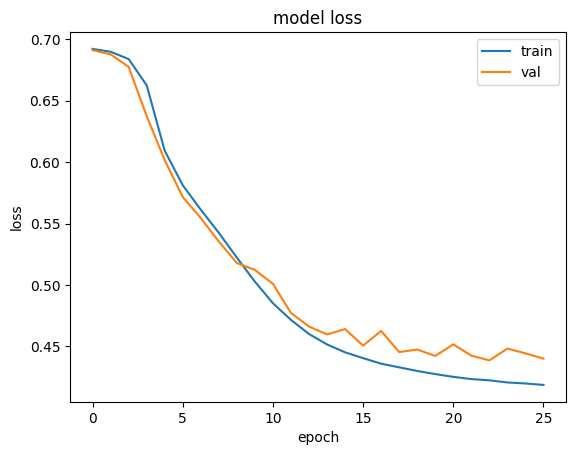

In [8]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [9]:
model3 = keras.Sequential()
model3.add(keras.layers.Embedding(500, 16, input_length=100))
model3.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))
model3.add(keras.layers.LSTM(8, dropout=0.3))
model3.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 나중에 실행시켜보기
rmsprop = keras.optimizers.RMSprop(learning_rate=0.0001)
model3.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2rnn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model3.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

# 그림
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [11]:
# GRU
model4 = keras.Sequential()
model4.add(keras.layers.Embedding(500, 16, input_length=100))
model4.add(keras.layers.GRU(8))
model4.add(keras.layers.Dense(1, activation='sigmoid'))
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# GRU를 이용한 텍스트 분류 모델

```python
# GRU
model4 = keras.Sequential()
model4.add(keras.layers.Embedding(500, 16, input_length=100))
model4.add(keras.layers.GRU(8))
model4.add(keras.layers.Dense(1, activation='sigmoid'))
model4.summary()
```

이 코드는 **GRU(Gated Recurrent Unit)** 를 사용하여 텍스트 데이터를 분류하는 순환 신경망 모델을 생성하는 코드이다.

---

# 전체 구조

```text
입력 문장
    ↓
Embedding
    ↓
GRU
    ↓
Dense
    ↓
Sigmoid
    ↓
분류 결과
```

예를 들어 영화 리뷰 감성 분석이라면

```text
영화 리뷰
    ↓
긍정일 확률
```

을 출력하게 된다.

---

# 1. Sequential 모델 생성

```python
model4 = keras.Sequential()
```

Sequential 모델은 층을 순서대로 쌓는 가장 단순한 신경망 모델이다.

현재 모델은

```text
Embedding
↓
GRU
↓
Dense
```

순서로 층이 연결된다.

---

# 2. Embedding 층

```python
model4.add(
    keras.layers.Embedding(
        500,
        16,
        input_length=100
    )
)
```

텍스트 데이터는 신경망이 직접 처리할 수 없기 때문에 숫자로 변환해야 한다.

예를 들어

```text
I love AI
```

↓

```text
[15, 72, 8]
```

처럼 단어 번호로 변환된다.

---

Embedding 층은 이 단어 번호를 의미를 가진 벡터로 바꾸어 준다.

예를 들어

```text
15
```

↓

```text
[0.25, -0.12, 0.88, ...]
```

(16개의 숫자)

---

## 파라미터 설명

### 500

```python
Embedding(500, ...)
```

사용할 단어 개수

```text
0 ~ 499
```

총 500개의 단어를 사용할 수 있다.

---

### 16

```python
Embedding(..., 16)
```

각 단어를

```text
16차원 벡터
```

로 표현한다.

---

### input_length=100

```python
input_length=100
```

문장의 길이를 100개 단어로 맞춘다는 의미이다.

---

## 출력 크기

입력

```python
(batch_size, 100)
```

↓

출력

```python
(batch_size, 100, 16)
```

---

예를 들어

```python
(32,100)
```

↓

```python
(32,100,16)
```

---

# 3. GRU 층

```python
model4.add(
    keras.layers.GRU(8)
)
```

GRU는 순환 신경망(RNN)의 한 종류이다.

---

## GRU의 역할

문장의 순서를 기억하면서 중요한 정보를 추출한다.

예를 들어

```text
I love AI
```

와

```text
AI love I
```

는 단어는 같지만 의미가 다르다.

GRU는 단어 순서를 고려하여 학습할 수 있다.

---

## GRU(8)

```python
GRU(8)
```

의 의미는

```text
GRU 유닛 8개 사용
```

이다.

---

즉 문장 전체 정보를

```text
8개의 특징값
```

으로 요약한다.

---

## 입력 크기

Embedding 출력

```python
(batch_size,100,16)
```

---

의미

```text
100개 단어
↓
각 단어는 16개 특징
```

---

## 출력 크기

```python
(batch_size,8)
```

---

예를 들어

```python
(32,100,16)
```

↓

```python
(32,8)
```

---

왜 100이 사라질까?

GRU는 마지막 시점의 은닉 상태만 출력하기 때문이다.

```text
단어1
단어2
...
단어100

↓
마지막 은닉 상태
```

만 사용한다.

---

# 4. Dense 출력층

```python
model4.add(
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
)
```

---

## Dense(1)

출력 노드 개수

```text
1개
```

---

예를 들어

```text
긍정 리뷰일 확률
```

하나만 출력한다.

---

## Sigmoid

```python
activation='sigmoid'
```

시그모이드 함수

$$
\sigma(x)
=
\frac{1}{1+e^{-x}}
$$

---

출력 범위

$$
0 \le y \le 1
$$

---

예시

```text
0.93
```

↓

```text
긍정 리뷰일 확률 93%
```

---

```text
0.04
```

↓

```text
부정 리뷰일 확률 96%
```

---

# 5. model.summary()

```python
model4.summary()
```

모델 구조를 출력한다.

예시

```text
Layer (type)          Output Shape
=====================================
embedding             (None,100,16)
gru                   (None,8)
dense                 (None,1)
=====================================
```

---

# 출력 크기 변화

| 층 | 출력 크기 |
|------|------|
| 입력 | (100,) |
| Embedding | (100,16) |
| GRU | (8,) |
| Dense | (1,) |

---

# 전체 데이터 흐름

```text
입력 문장
(100개 단어)

        ↓

Embedding
(500 → 16차원)

        ↓

(100,16)

        ↓

GRU(8)

        ↓

(8)

        ↓

Dense(1)

        ↓

Sigmoid

        ↓

긍정/부정 확률 출력
```

---

# 핵심 요약

- Embedding 층은 단어 번호를 16차원 벡터로 변환한다.
- GRU(8)은 문장의 순서를 고려하여 정보를 학습하고 8개의 특징으로 요약한다.
- Dense(1)은 하나의 출력값을 생성한다.
- Sigmoid는 출력값을 확률로 변환한다.
- 이 모델은 대표적인 GRU 기반 이진 텍스트 분류 모델이다.

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model4.compile(
    optimizer=rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-gru-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True)
history = model4.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()